In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

In [18]:
# Step 2
rawInsideData = pd.read_csv('https://raw.githubusercontent.com/jgrant559-beep/E11---Jenna-Dakota-and-Ethan-/refs/heads/main/Week5/inside_data.csv')
rawOutsideData = pd.read_csv('https://raw.githubusercontent.com/jgrant559-beep/E11---Jenna-Dakota-and-Ethan-/refs/heads/main/Week5/outside_data.csv')

otherInsideData = pd.read_csv("https://raw.githubusercontent.com/jgrant559-beep/E11---Jenna-Dakota-and-Ethan-/refs/heads/main/Week6/OtherGroup'sData/air_weather_indoors.csv")
otherOutsideData = pd.read_csv("https://raw.githubusercontent.com/jgrant559-beep/E11---Jenna-Dakota-and-Ethan-/refs/heads/main/Week6/OtherGroup'sData/air_weather_outdoors.csv")

insideData = rawInsideData[1:].reset_index(drop=True)
outsideData = rawOutsideData[60:].reset_index(drop=True)

# Rearranging the other data to match the format of our data
otherInsideData = otherInsideData.drop(columns=["pm25_standard", "pm100_standard", "pm25_env", "pm10_standard", "particles_05um", "particles_10um", "particles_25um", "particles_50um", "particles_100um"])
otherInsideData = otherInsideData.rename(columns={"Tempreature": "Temperature",
                                                 "t_s": "time",
                                                 "particles_03um": "Particles > 0.3um / 0.1L air"})
otherInsideData = otherInsideData[["time", "Particles > 0.3um / 0.1L air", "Temperature", "Gas", "Humidity", "Pressure", "Altitude"]]

otherOutsideData = otherOutsideData.drop(columns=["pm25_standard", "pm100_standard", "pm25_env", "pm10_standard", "particles_05um", "particles_10um", "particles_25um", "particles_50um", "particles_100um"])
otherOutsideData = otherOutsideData.rename(columns={"Tempreature": "Temperature",
                                                 "t_s": "time",
                                                 "particles_03um": "Particles > 0.3um / 0.1L air"})
otherOutsideData = otherOutsideData[["time", "Particles > 0.3um / 0.1L air", "Temperature", "Gas", "Humidity", "Pressure", "Altitude"]]

otherInsideData = otherInsideData[1:].reset_index(drop=True)
otherOutsideData = otherOutsideData[1:].reset_index(drop=True)
display(otherOutsideData)

,time,Particles > 0.3um / 0.1L air,Temperature,Gas,Humidity,Pressure,Altitude
0,1,192,22.6,26440,34.8,1006.149,59.29
1,2,210,22.6,45355,34.8,1006.186,58.98
2,3,210,22.6,61190,34.7,1006.202,58.85
3,4,210,22.6,73395,34.6,1006.214,58.75
4,5,198,22.6,83569,34.5,1006.230,58.61
...,...,...,...,...,...,...,...
291,295,717,16.8,162059,42.2,1007.439,48.49
292,296,741,16.8,167323,42.2,1007.445,48.44
293,297,741,16.8,168484,42.2,1007.444,48.45
294,298,741,16.7,171544,42.2,1007.438,48.50


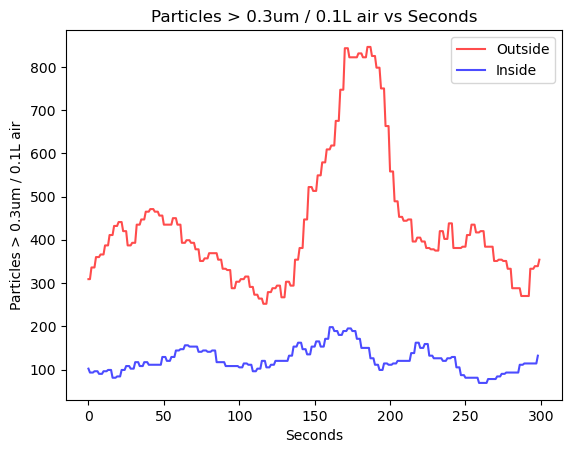

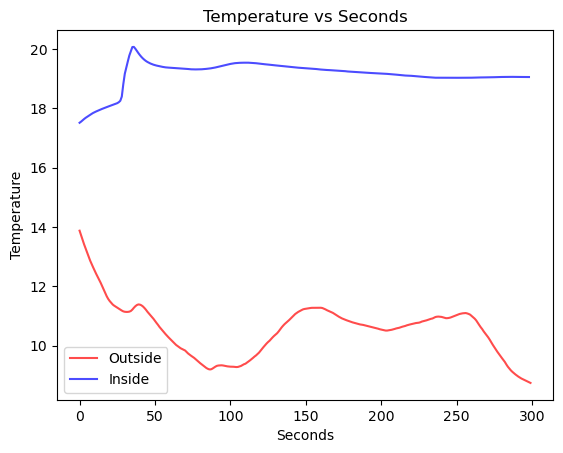

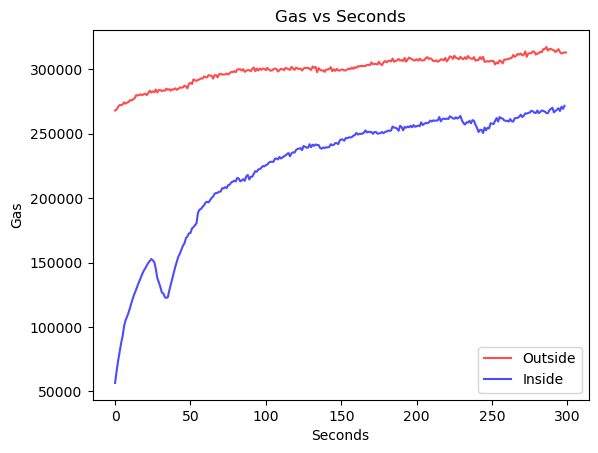

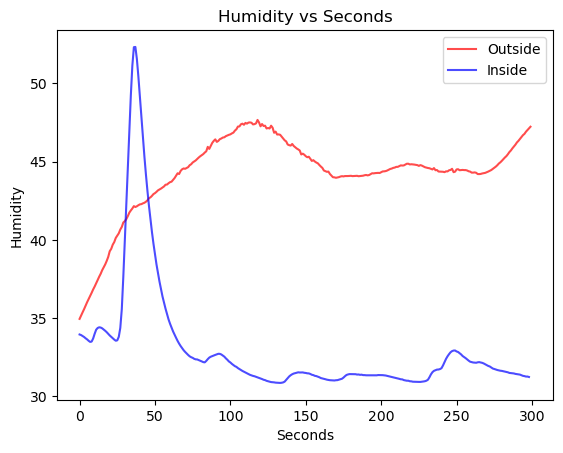

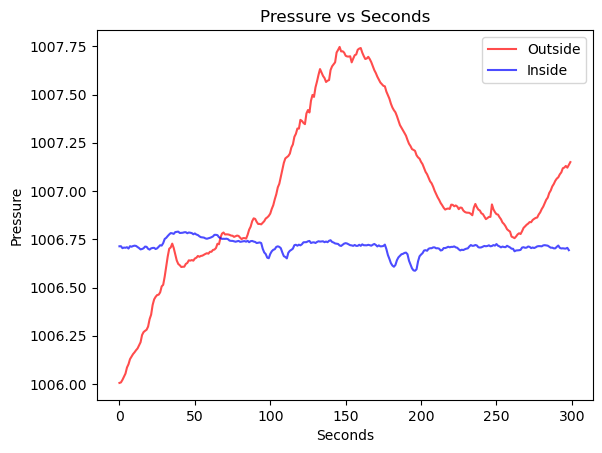

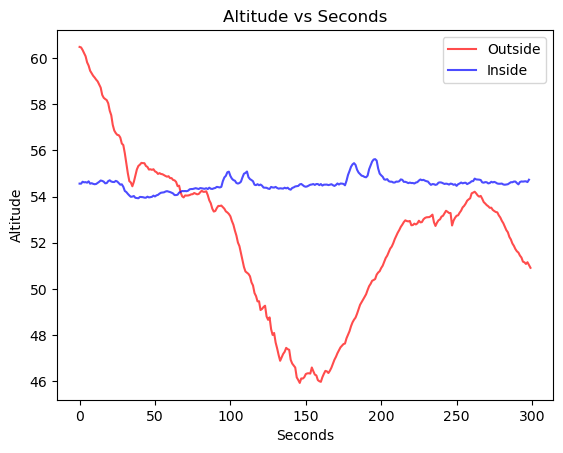

In [19]:
#Plots 
column_names = rawInsideData.columns

for i in range(6): 
    currentLabel = column_names[i+1]
    
    plt.plot(outsideData.iloc[: , i+1], label="Outside", alpha = .7, color = "red")
    plt.plot(insideData.iloc[:, i+1], label="Inside", alpha = .7, color = "blue")
    plt.ylabel(currentLabel)
    plt.xlabel("Seconds")
    plt.title(currentLabel + " vs Seconds") 
    plt.legend()
    plt.show()

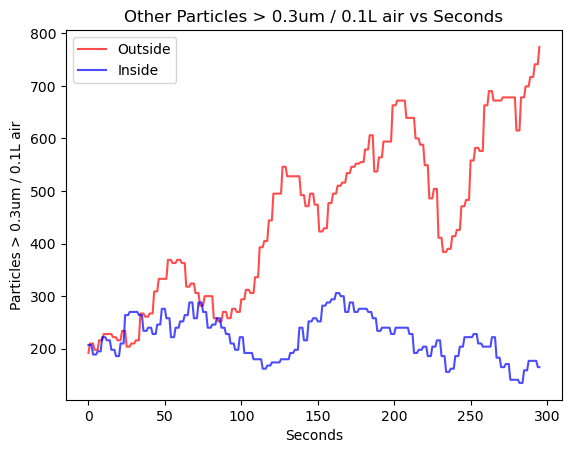

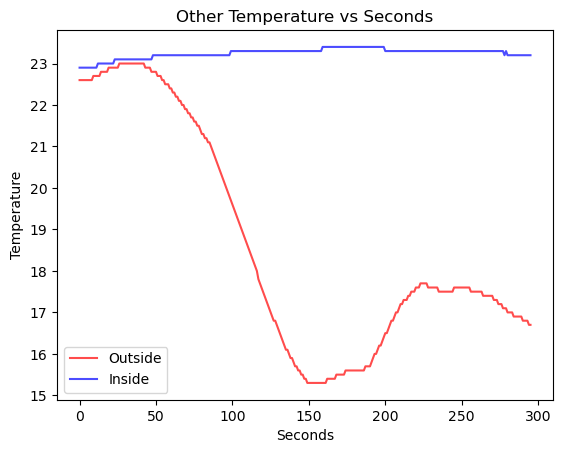

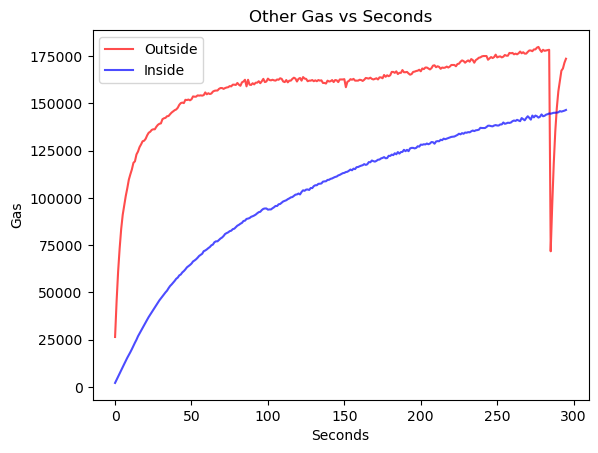

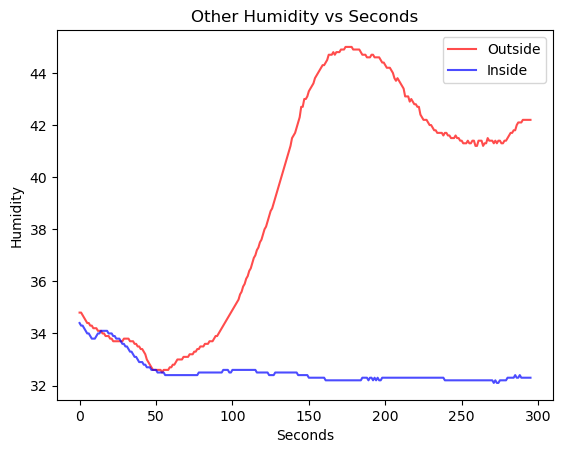

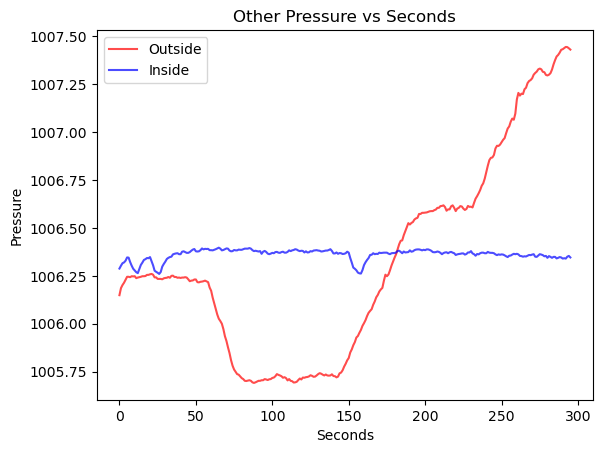

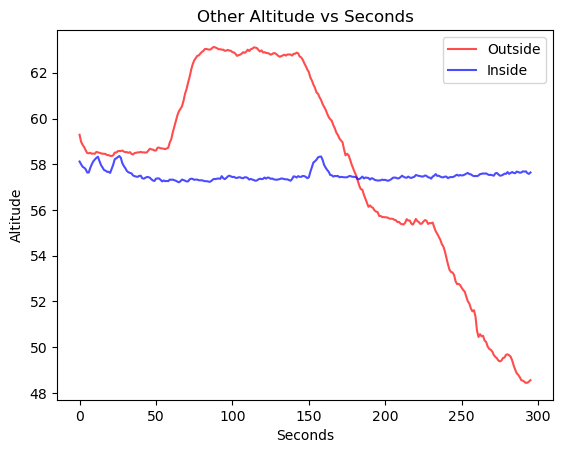

In [20]:
#Plots 
column_names = otherInsideData.columns

for i in range(6): 
    currentLabel = column_names[i+1]
    
    plt.plot(otherOutsideData.iloc[: , i+1], label="Outside", alpha = .7, color = "red")
    plt.plot(otherInsideData.iloc[:, i+1], label="Inside", alpha = .7, color = "blue")
    plt.ylabel(currentLabel)
    plt.xlabel("Seconds")
    plt.title("Other " + currentLabel + " vs Seconds") 
    plt.legend()
    plt.show()

In [21]:
def compare_datas(ours, other, where):
    column_names = ours.columns

    for i in range(6): 
        currentLabel = column_names[i+1]
        
        plt.plot(ours.iloc[: , i+1], label=f"Our {where}", alpha = .7, color = "red")
        plt.plot(other.iloc[:, i+1], label=f"Other {where}", alpha = .7, color = "blue")
        plt.ylabel(currentLabel)
        plt.xlabel("Seconds")
        plt.title(currentLabel + " vs Seconds") 
        plt.legend()
        plt.show()

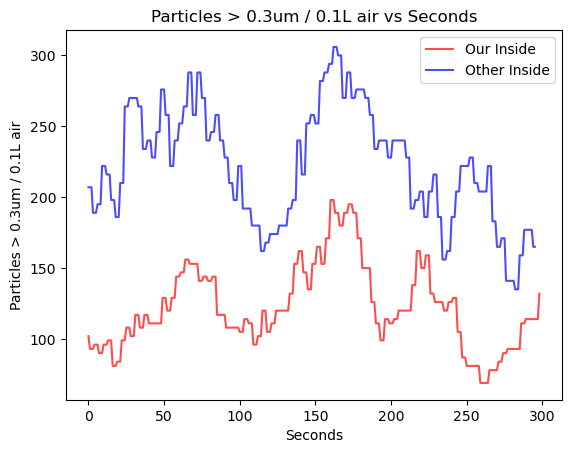

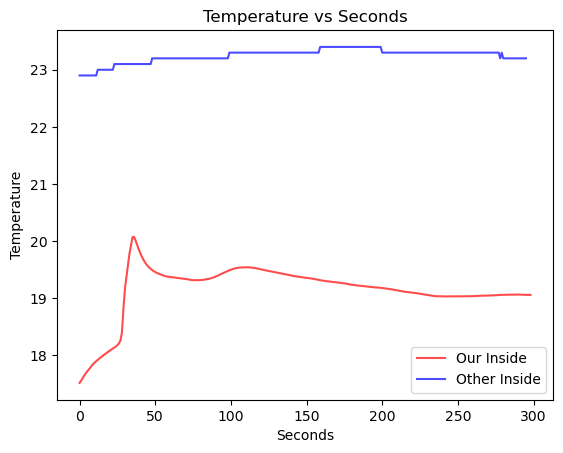

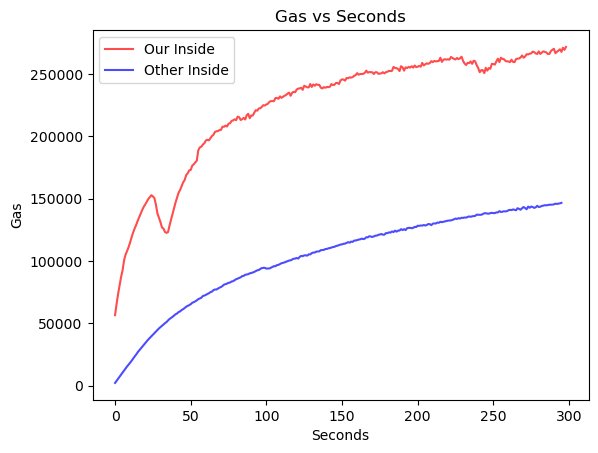

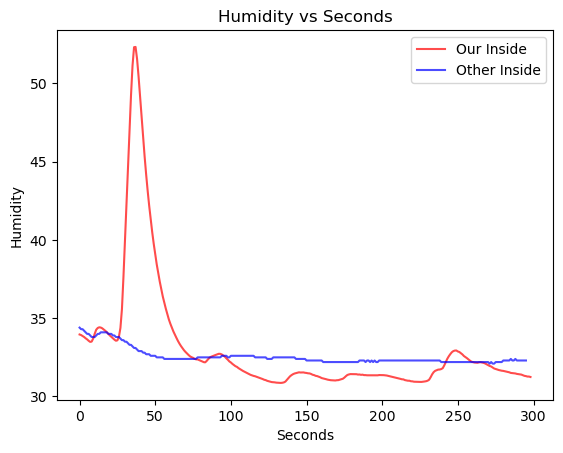

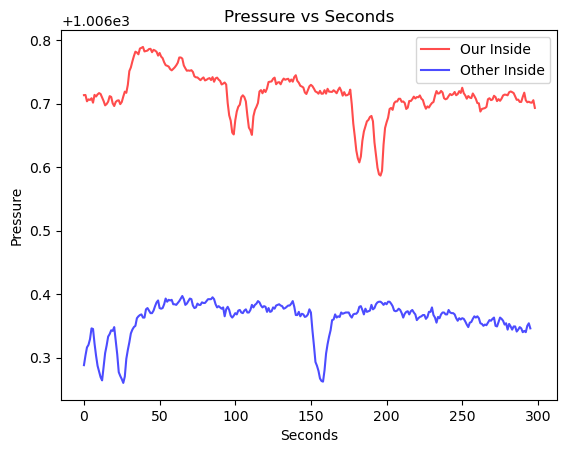

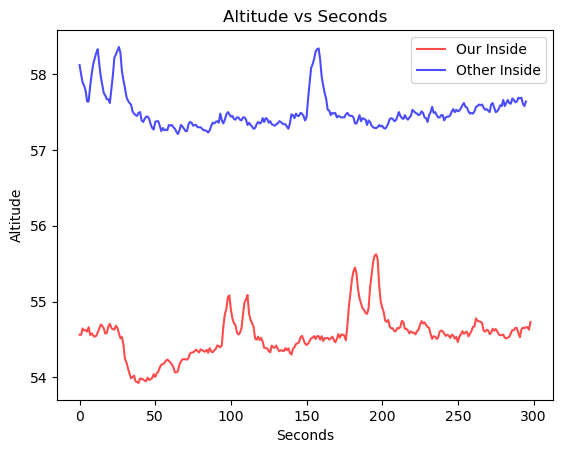

In [22]:
compare_datas(insideData, otherInsideData, "Inside")

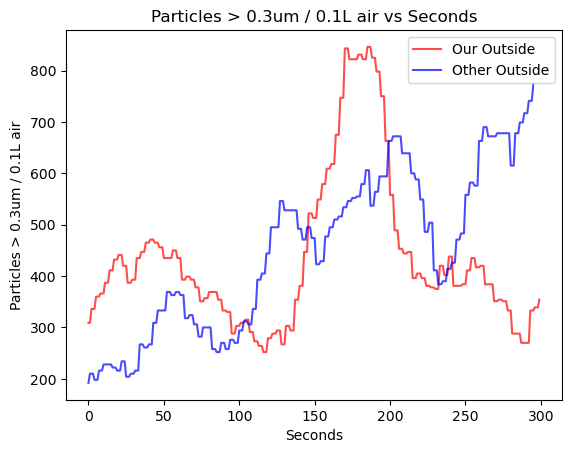

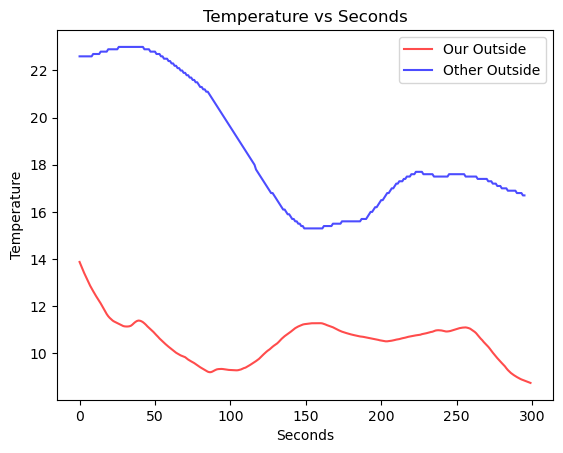

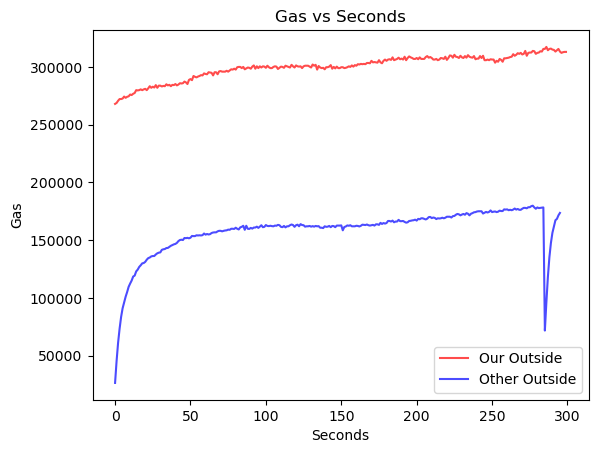

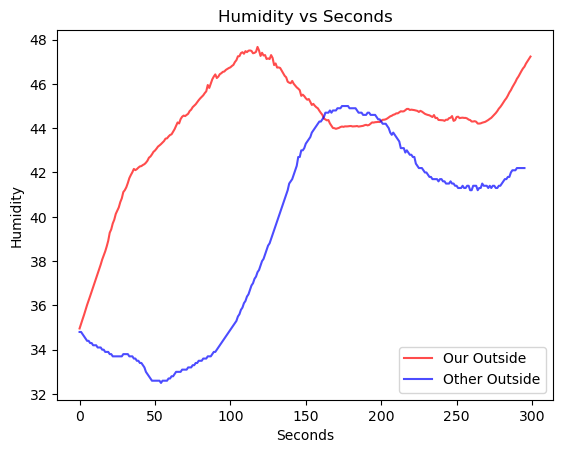

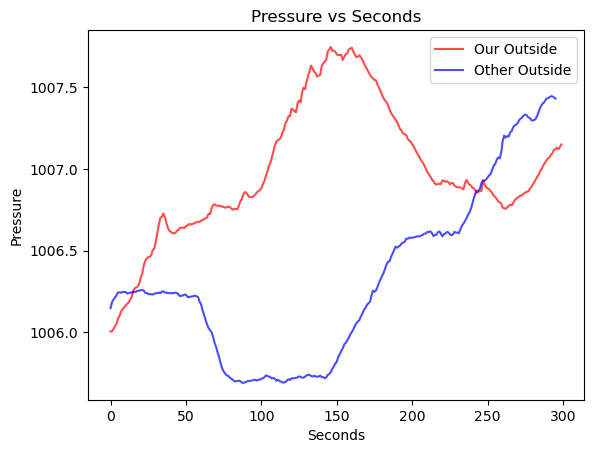

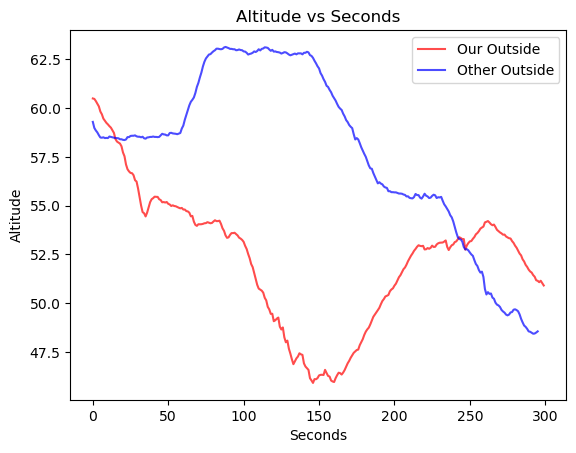

In [23]:
compare_datas(outsideData, otherOutsideData, "Outside")

In [24]:
#Histograms & Error Analysis
column_names = otherInsideData.columns
def compare_histograms(ours, other, where):
    for i in range(6): 
        currentLabel = column_names[i+1]
        currentOurs = ours.iloc[: , i+1]
        currentOther = other.iloc[: , i+1]
        
        meansOurs = currentOurs.mean()
        meansOther = currentOther.mean()
        
        stdOurs = currentOurs.std()
        stdOther = currentOther.std()
    
        meanUncertiantyOurs = stdOurs / math.sqrt(currentOurs.size)
        meanUncertiantyOther = stdOther / math.sqrt(currentOther.size)
    
        standardErr = math.sqrt((stdOther ** 2 / (currentOther.size))+(stdOurs ** 2 / (currentOurs.size)))
    
        print(f"Mean Uncertainty Our {where} Data: " + str(meanUncertiantyOurs)) 
        print(f"Mean Uncertainty Other {where} Data: " + str(meanUncertiantyOther)) 
        
        print("Difference in mean standard deviations: " + str(standardErr))
    
        print("Difference in means is > 3σ : " + str(abs(meansOurs-meansOther) > (3 * standardErr)))
            
        
        plt.hist(currentOurs, label=f"Our {where}", alpha = .7, color = "red")
        plt.hist(currentOther, label=f"Other {where}", alpha = .7, color = "blue")
        plt.xlabel(currentLabel)
        plt.ylabel("Frequency") 
        plt.title(f"{currentLabel} Histograms")
        plt.legend()
        plt.show()

Mean Uncertainty Our Inside Data: 1.6953365697716154
Mean Uncertainty Other Inside Data: 2.3513288418844556
Difference in mean standard deviations: 2.898777916205842
Difference in means is > 3σ : True


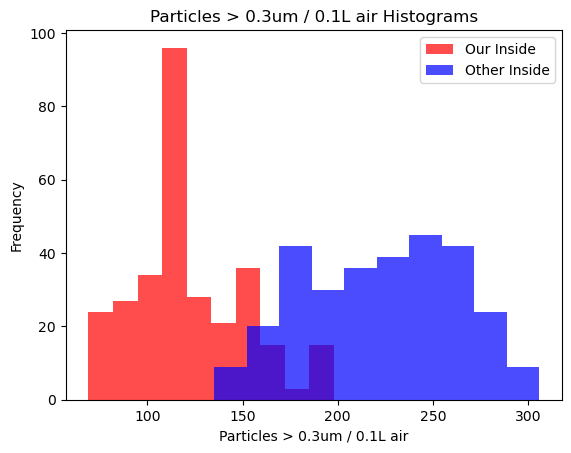

Mean Uncertainty Our Inside Data: 0.02602765750533304
Mean Uncertainty Other Inside Data: 0.006899432699249977
Difference in mean standard deviations: 0.026926587730093078
Difference in means is > 3σ : True


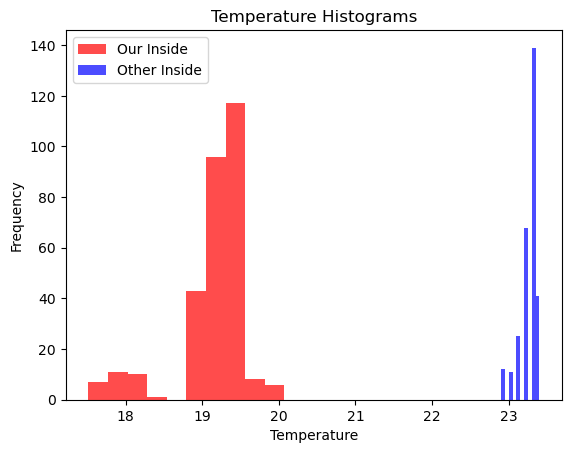

Mean Uncertainty Our Inside Data: 2765.31633630415
Mean Uncertainty Other Inside Data: 2125.8136564857855
Difference in mean standard deviations: 3487.9876923424013
Difference in means is > 3σ : True


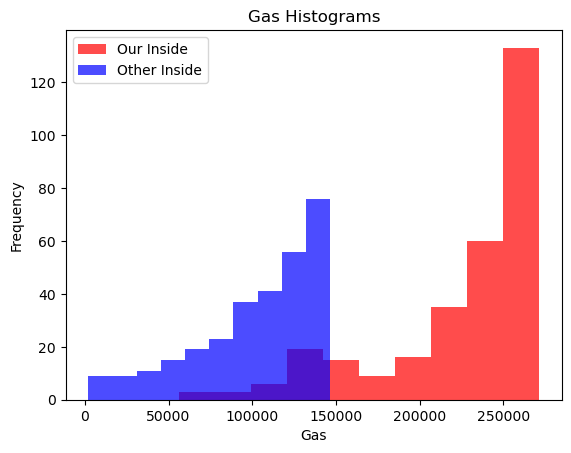

Mean Uncertainty Our Inside Data: 0.22427955691411783
Mean Uncertainty Other Inside Data: 0.030538265231707287
Difference in mean standard deviations: 0.2263490784009405
Difference in means is > 3σ : False


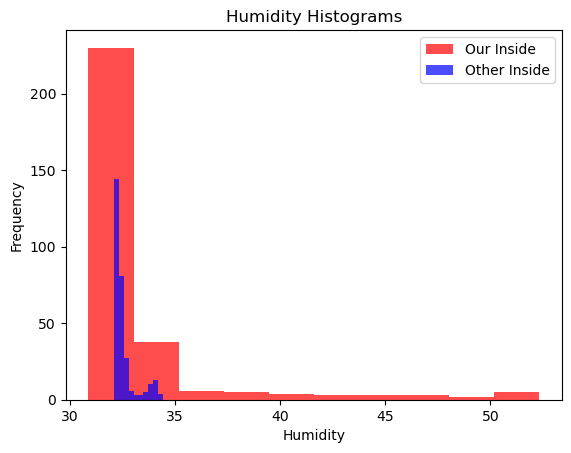

Mean Uncertainty Our Inside Data: 0.001996714676900354
Mean Uncertainty Other Inside Data: 0.0016669641891486852
Difference in mean standard deviations: 0.002601084217947089
Difference in means is > 3σ : True


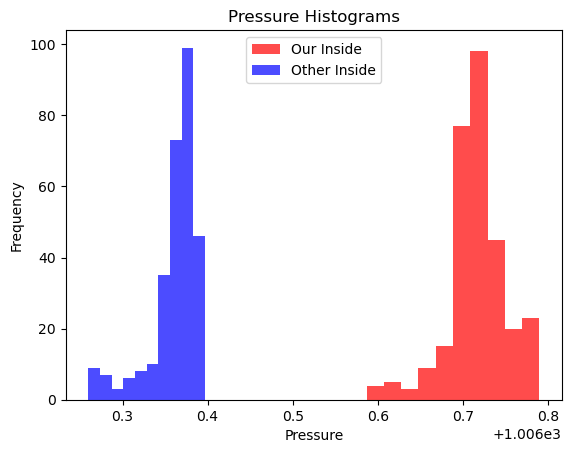

Mean Uncertainty Our Inside Data: 0.016711488803741494
Mean Uncertainty Other Inside Data: 0.013937680956985067
Difference in mean standard deviations: 0.021760809003717702
Difference in means is > 3σ : True


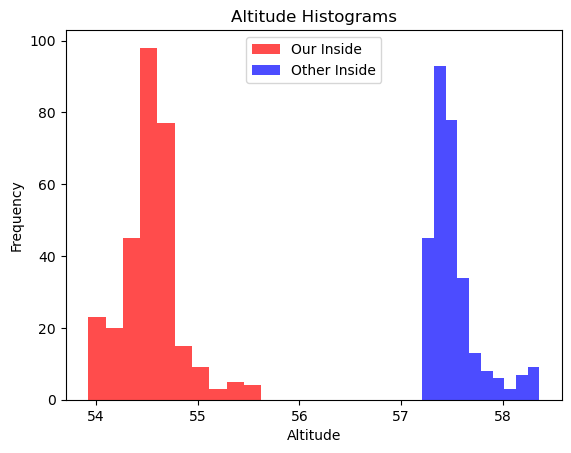

In [25]:
compare_histograms(insideData, otherInsideData, "Inside")

Mean Uncertainty Our Outside Data: 8.696621013753342
Mean Uncertainty Other Outside Data: 9.129611384775943
Difference in mean standard deviations: 12.60876762788048
Difference in means is > 3σ : False


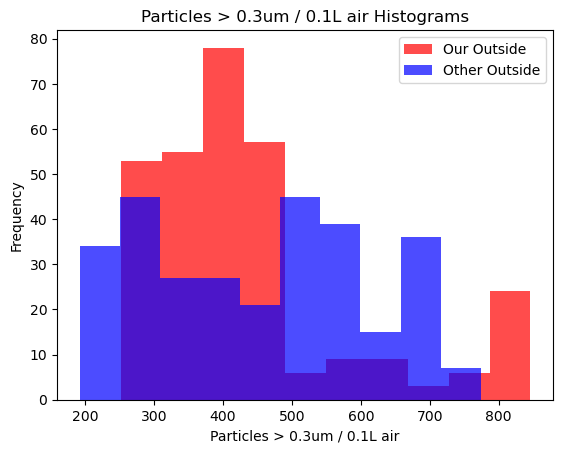

Mean Uncertainty Our Outside Data: 0.0530318515630481
Mean Uncertainty Other Outside Data: 0.15789931512651773
Difference in mean standard deviations: 0.1665670165357731
Difference in means is > 3σ : True


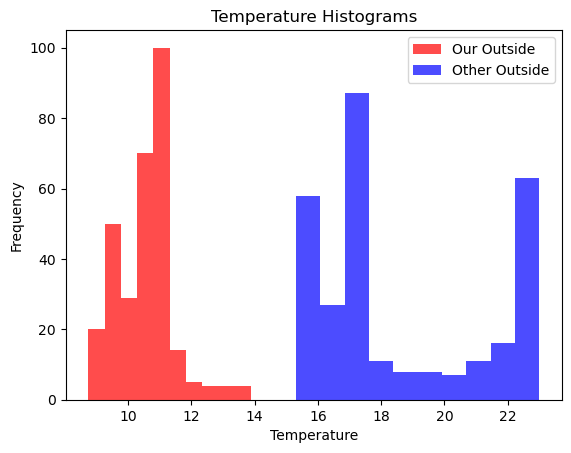

Mean Uncertainty Our Outside Data: 604.5459829680588
Mean Uncertainty Other Outside Data: 1213.3468353075154
Difference in mean standard deviations: 1355.6129197796765
Difference in means is > 3σ : True


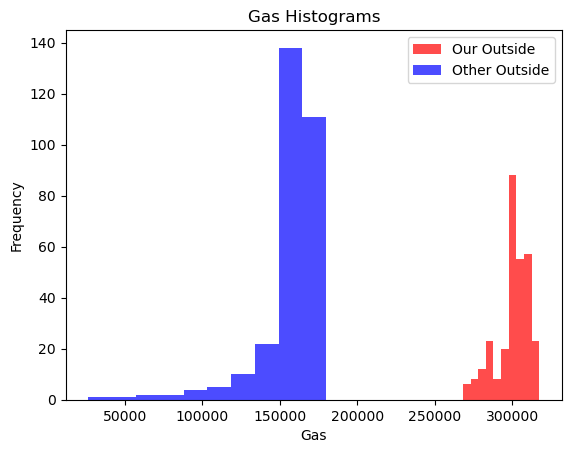

Mean Uncertainty Our Outside Data: 0.14547410164852745
Mean Uncertainty Other Outside Data: 0.2584934985998444
Difference in mean standard deviations: 0.2966169298418987
Difference in means is > 3σ : True


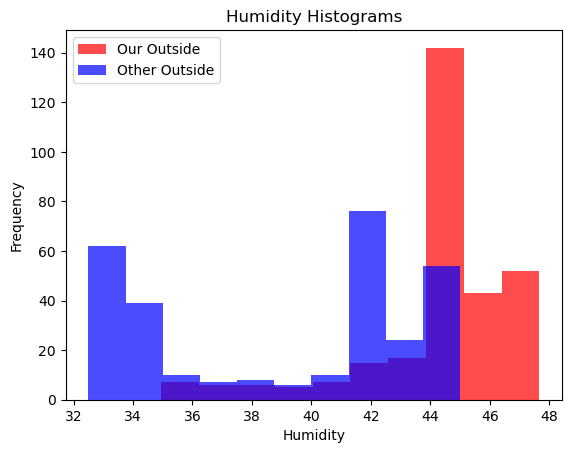

Mean Uncertainty Our Outside Data: 0.023663016129724386
Mean Uncertainty Other Outside Data: 0.03034803063260205
Difference in mean standard deviations: 0.03848300008618025
Difference in means is > 3σ : True


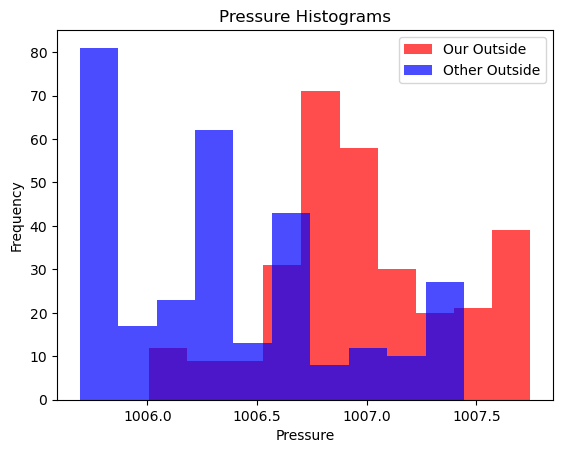

Mean Uncertainty Our Outside Data: 0.1980007847822209
Mean Uncertainty Other Outside Data: 0.2540712644312279
Difference in mean standard deviations: 0.32211258619317923
Difference in means is > 3σ : True


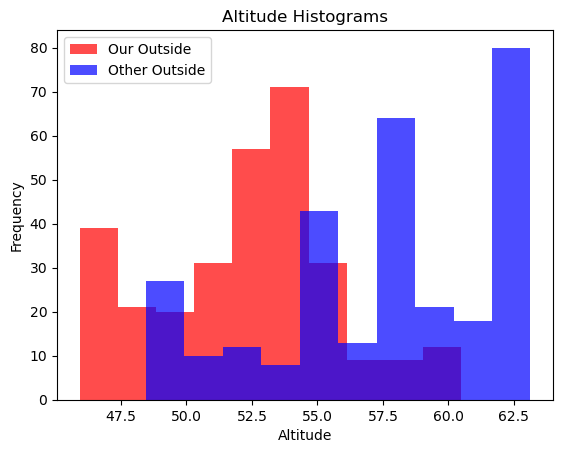

In [26]:
compare_histograms(outsideData, otherOutsideData, "Outside")

In [27]:
# Step 3
location1 = outsideData
location2 = pd.read_csv("https://raw.githubusercontent.com/jgrant559-beep/E11---Jenna-Dakota-and-Ethan-/refs/heads/main/Week6/strawberry_creek.csv")

location2 = location2[1:].reset_index(drop=True)
display(location2)

,time,Particles > 0.3um / 0.1L air,Temperature,Gas,Humidity,Pressure,Altitude
0,15:15:02,0,22.952852,25686,38.521437,1010.768691,20.679102
1,15:15:03,0,23.050313,38706,38.741225,1010.818772,20.261323
2,15:15:04,0,23.143281,50724,38.356499,1010.802552,20.396634
3,15:15:05,0,23.234883,61483,38.216968,1010.790927,20.493611
4,15:15:06,0,23.329414,70449,38.077833,1010.782412,20.564641
...,...,...,...,...,...,...,...
294,15:19:59,108,22.155781,279071,40.562889,1011.382541,15.559486
295,15:20:00,108,22.135273,279071,40.651326,1011.377655,15.600224
296,15:20:01,93,22.114180,280017,40.866873,1011.378695,15.591553
297,15:20:02,93,22.087812,278132,40.948747,1011.377834,15.598731


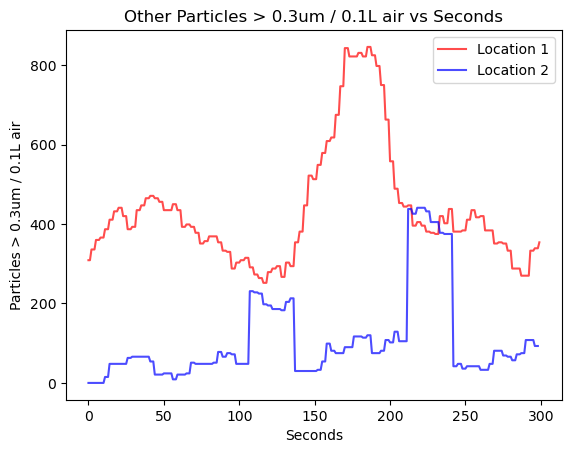

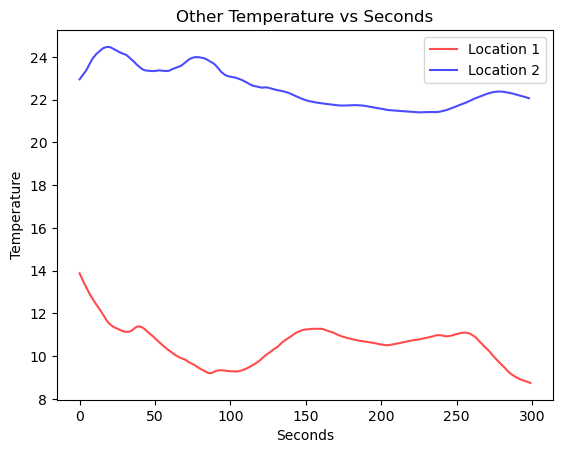

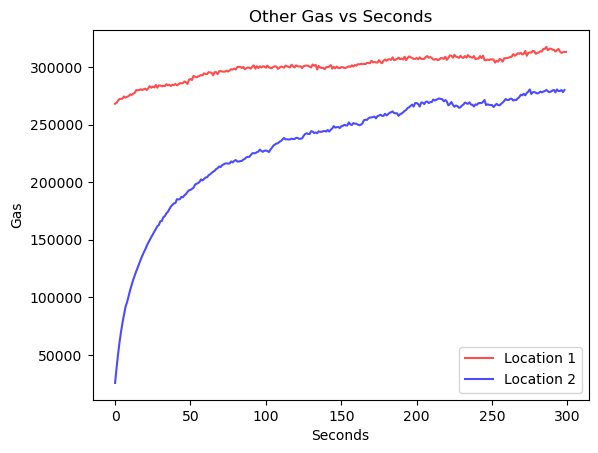

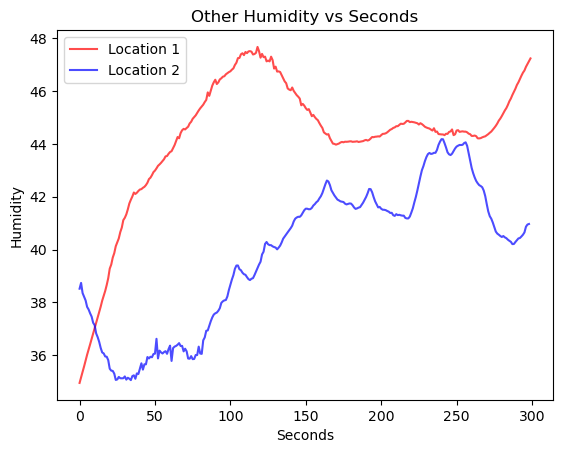

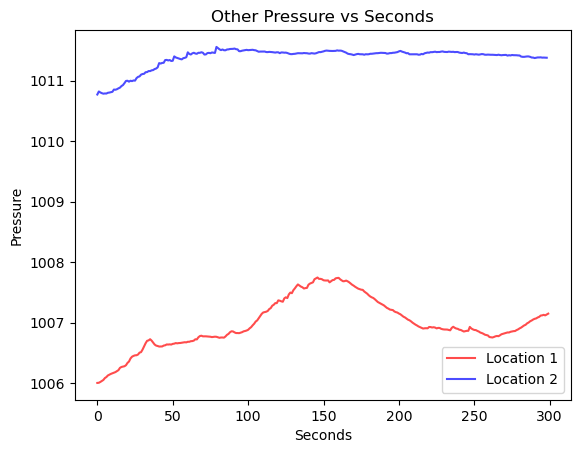

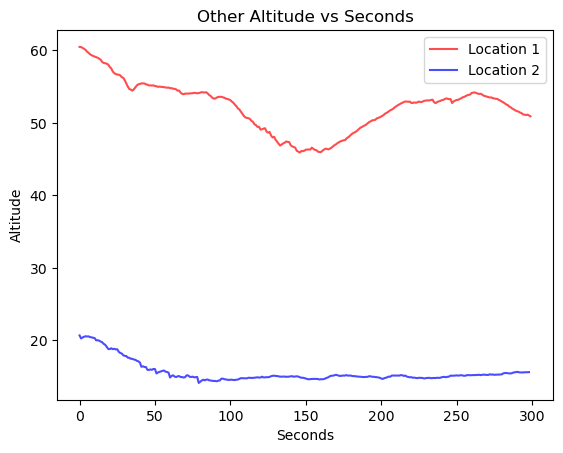

In [28]:
for i in range(6): 
    currentLabel = column_names[i+1]
    
    plt.plot(location1.iloc[: , i+1], label="Location 1", alpha = .7, color = "red")
    plt.plot(location2.iloc[:, i+1], label="Location 2", alpha = .7, color = "blue")
    plt.ylabel(currentLabel)
    plt.xlabel("Seconds")
    plt.title("Other " + currentLabel + " vs Seconds") 
    plt.legend()
    plt.show()

Mean Uncertainty location 1 Data: 8.696621013753342
Mean Uncertainty location 2 Data: 6.612648809521929
Difference in mean standard deviations: 10.925124316680703
Difference in means is > 3σ : True


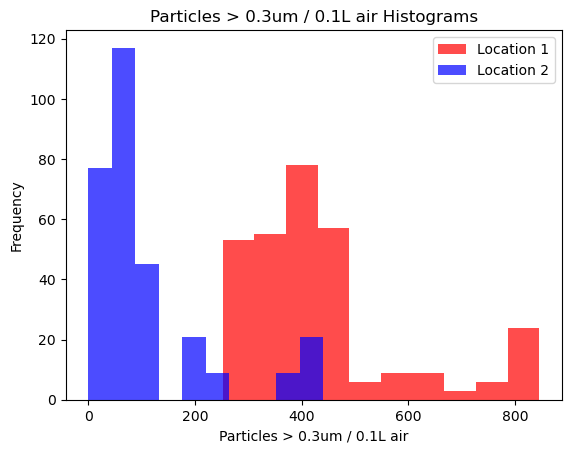

Mean Uncertainty location 1 Data: 0.0530318515630481
Mean Uncertainty location 2 Data: 0.05366836636889983
Difference in mean standard deviations: 0.07544979011840673
Difference in means is > 3σ : True


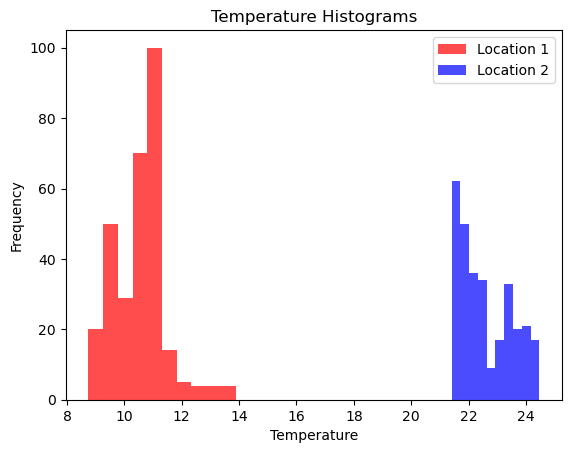

Mean Uncertainty location 1 Data: 604.5459829680588
Mean Uncertainty location 2 Data: 2842.6121857566977
Difference in mean standard deviations: 2906.1864847485763
Difference in means is > 3σ : True


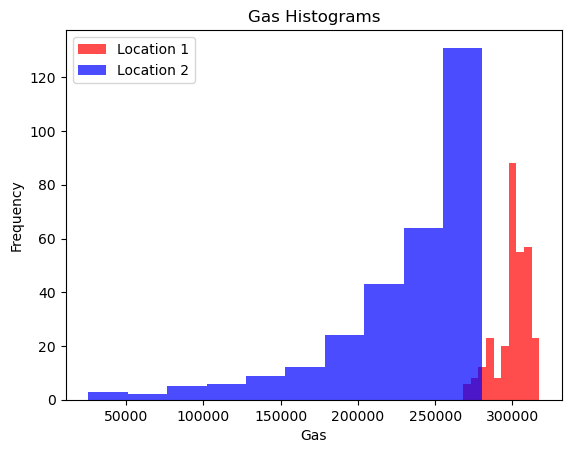

Mean Uncertainty location 1 Data: 0.14547410164852745
Mean Uncertainty location 2 Data: 0.15798722177544872
Difference in mean standard deviations: 0.2147619065262062
Difference in means is > 3σ : True


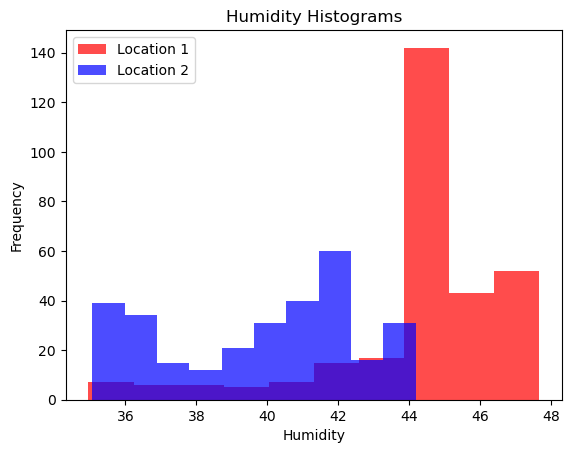

Mean Uncertainty location 1 Data: 0.023663016129724386
Mean Uncertainty location 2 Data: 0.01021375713060892
Difference in mean standard deviations: 0.02577322577945301
Difference in means is > 3σ : True


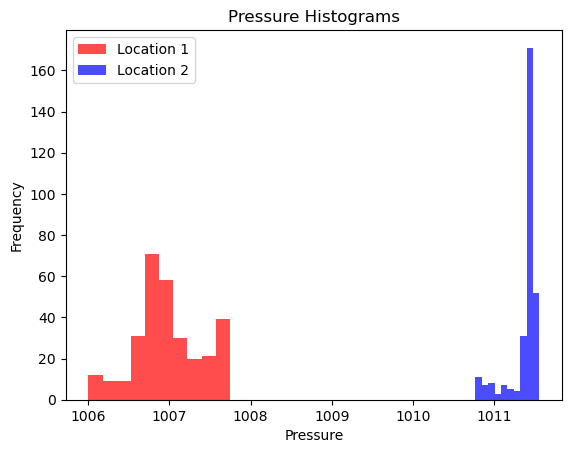

Mean Uncertainty location 1 Data: 0.1980007847822209
Mean Uncertainty location 2 Data: 0.08517731212060772
Difference in mean standard deviations: 0.21554462478676384
Difference in means is > 3σ : True


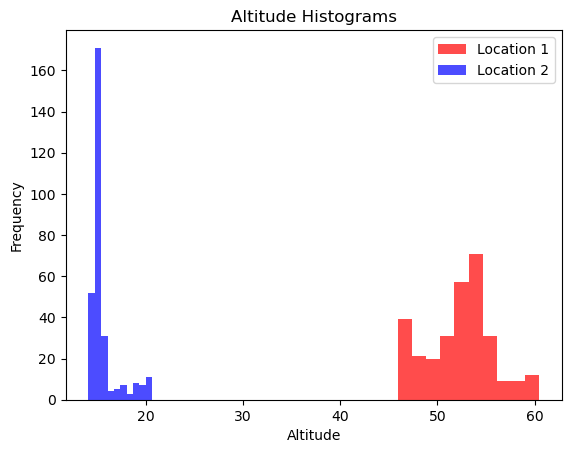

In [29]:
for i in range(6): 
    currentLabel = column_names[i+1]
    current1 = location1.iloc[: , i+1]
    current2 = location2.iloc[: , i+1]
    
    means1 = current1.mean()
    means2 = current2.mean()
    
    std1 = current1.std()
    std2 = current2.std()

    meanUncertianty1 = std1 / math.sqrt(current1.size)
    meanUncertianty2 = std2 / math.sqrt(current2.size)

    standardErr = math.sqrt((std2 ** 2 / (current2.size))+(std1 ** 2 / (current1.size)))

    print(f"Mean Uncertainty location 1 Data: " + str(meanUncertianty1)) 
    print(f"Mean Uncertainty location 2 Data: " + str(meanUncertianty2)) 
    
    print("Difference in mean standard deviations: " + str(standardErr))

    print("Difference in means is > 3σ : " + str(abs(means1-means2) > (3 * standardErr)))
        
    
    plt.hist(current1, label="Location 1", alpha = .7, color = "red")
    plt.hist(current2, label="Location 2", alpha = .7, color = "blue")
    plt.xlabel(currentLabel)
    plt.ylabel("Frequency") 
    plt.title(f"{currentLabel} Histograms")
    plt.legend()
    plt.show()